In [1]:
# Step 1: Load Dataset
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [3]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [4]:
df["review"] = df["review"].str.lower()

In [5]:
# Step 2: Sentiment Analysis (VADER)
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    return "positive" if score > 0 else "negative"

df["predicted_sentiment"] = df["review"].apply(get_sentiment)


[nltk_data] Downloading package vader_lexicon to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [6]:
# Step 3: Accuracy
from sklearn.metrics import accuracy_score

acc = accuracy_score(df["sentiment"], df["predicted_sentiment"])
print("Accuracy:", acc)

Accuracy: 0.69614


In [7]:
# Step 4: Keyword Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words='english', max_features=1000)
X = vec.fit_transform(df["review"])
features = vec.get_feature_names_out()

In [8]:
# Top keywords (first 5 reviews)
for i in range(5):
    row = X[i].toarray()[0]
    top = row.argsort()[-3:]
    print(df["review"].iloc[i])
    print([features[j] for j in top])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fac

<Axes: title={'center': 'Sentiment Distribution'}, xlabel='predicted_sentiment'>

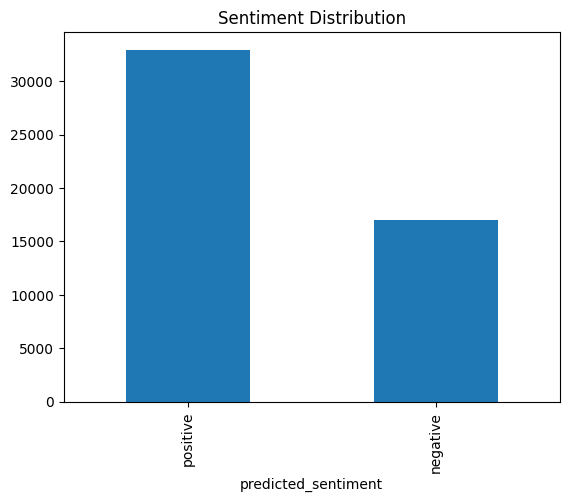

In [9]:
# Step 5: Sentiment Distribution
df["predicted_sentiment"].value_counts().plot(kind='bar', title="Sentiment Distribution")

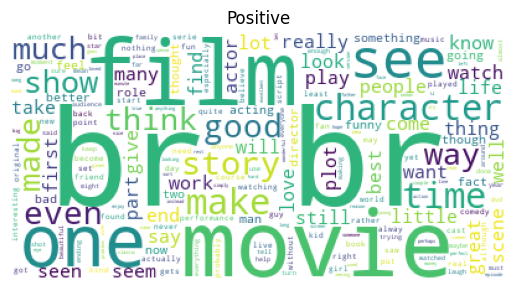

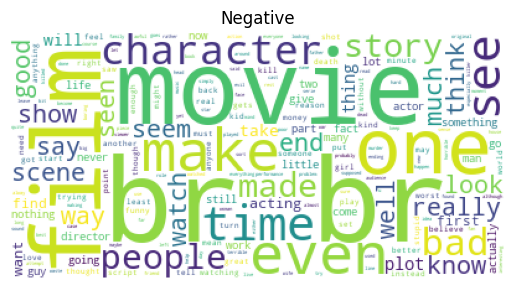

In [10]:
# Step 6: WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

pos = " ".join(df[df["predicted_sentiment"] == "positive"]["review"])
neg = " ".join(df[df["predicted_sentiment"] == "negative"]["review"])

for text, title in [(pos, "Positive"), (neg, "Negative")]:
    plt.imshow(WordCloud(background_color='white').generate(text))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [13]:
# Step 7: User Input
text = input("Enter review: ").lower()

score = sia.polarity_scores(text)["compound"]
sentiment = "positive" if score >= 0 else "negative"

vec_input = vec.transform([text])
row = vec_input.toarray()[0]
top = row.argsort()[-3:]
keywords = [features[i] for i in top]

print("Sentiment:", sentiment)
print("Keywords:", keywords)

Enter review:  The movie was really good!


Sentiment: positive
Keywords: ['movie', 'good', 'really']
